# Notebook 02 — Event Definition & Detection
**Thesis Chapter 6** | **Input:** `data/1_reconstructed.csv` | **Output:** `data/2_events.csv`

---

## What this notebook does

Adds 10 event indicator columns to the reconstructed dataset.
An **event** is a binary or categorical condition at the time of each received packet.  
Example: *"Was CO₂ above 700 ppm when this packet arrived?"*

| Family | Events  | Why it matters                                                         |
|--------|---------|------------------------------------------------------------------------|
| Occupancy (CO₂) | E1, E2  | CO₂ is the best non-invasive proxy for human presence                  |
| Temporal | E3, E4   | Office activity follows predictable daily and seasonal cycles |
| Air Quality (PM2.5) | E5, E6  | PM2.5 spikes mark activity bursts — cleaning, printing, cooking        |
| Atmospheric | E7, E8  | Temperature, humidity                                                  |
| Spreading Factor | E9     | SF controls Time-on-Air and therefore collision probability            |
| Signal Quality | E10 | ESP — proxy for channel state at the time of each interval        |
| Burst Loss | ~ | Classifies loss episodes by severity (descriptive only)                |

Notebook 03 correlates these events with `PDR_link` (outage intervals excluded).


## 0 · Imports & Load

In [41]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '1_reconstructed.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)
df_link = df[~df['is_outage']].copy()

print(f'Rows (Outage excluded)  : {len(df_link):,}')
print(f'Devices : {sorted(df_link["device_id"].unique())}')
print(f'Campaign: {df_link["time"].min().date()} → {df_link["time"].max().date()}')

Rows (Outage excluded)  : 2,634,454
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign: 2024-10-01 → 2025-09-30


In [42]:
print(f"Total rows          : {len(df):,}")
print(f"is_outage == True   : {df['is_outage'].sum():,}")
print(f"is_outage == False  : {(~df['is_outage']).sum():,}")

# Show a sample of outage-flagged rows
print(df[df['is_outage']].head(10)[['device_id','time','is_outage','tx_loss']])

Total rows          : 2,634,930
is_outage == True   : 476
is_outage == False  : 2,634,454
      device_id                             time  is_outage  tx_loss
10885       ED0 2024-10-09 14:19:06.895087+00:00       True        0
10886       ED0 2024-10-09 14:44:19.456632+00:00       True       26
11879       ED0 2024-10-10 11:45:31.212935+00:00       True       79
11880       ED0 2024-10-10 15:09:39.585465+00:00       True      189
13057       ED0 2024-10-11 13:24:53.337752+00:00       True        0
13058       ED0 2024-10-11 13:51:03.046179+00:00       True       36
13091       ED0 2024-10-11 15:36:07.553349+00:00       True       66
14611       ED0 2024-10-13 12:45:52.515311+00:00       True      882
15859       ED0 2024-10-14 14:44:45.790776+00:00       True       10
15860       ED0 2024-10-14 15:12:47.081866+00:00       True       25


In [43]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family':'serif','font.size':12,'axes.titlesize':13,
    'axes.labelsize':13,'xtick.labelsize':12,'ytick.labelsize':12,
    'legend.fontsize':11,'figure.dpi':150,'savefig.dpi':300,
    'savefig.bbox':'tight','axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
})
C = {'blue':'#0077BB','orange':'#EE7733','green':'#009988',
     'red':'#CC3311','purple':'#AA3377','navy':'#004488','grey':'#BBBBBB',
     'brown':'#882255','teal':'#44AA99','yellow':'#DDCC77'}
DEVICE_COLORS = [C['blue'],C['orange'],C['green'],C['red'],C['purple'],C['navy']]
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}
FIG_DIR = Path('../figures/2'); FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR/f'{name}.pdf')
    fig.savefig(FIG_DIR/f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()

print('Figures settings ready.')


Figures settings ready.


## 1 · Occupancy Events — CO₂  *(§6.1)*

CO₂ rises linearly with the number of people present — human metabolism produces ~200 ml CO₂/min at rest.  
Outdoor ambient is ~420 ppm. Weekday mean in this building is ~576 ppm vs ~457 ppm on weekends,  
confirming CO₂ as a reliable occupancy proxy.

| Event | Definition                                                         |
|-------|--------------------------------------------------------------------|
| E1 | CO₂ tier: background (<500) / moderate (500–700) / high (>700 ppm) |
| E2 | CO₂ rising: delta > 15 ppm per 60s — occupancy actively increasing |

In [44]:
# E1: CO2 tier — 500 ppm = outdoor ambient ceiling, 700 ppm = moderate occupancy onset
df['e1_co2_tier'] = pd.cut(
    df['co2'],
    bins=[0, 500, 700, 10_000],
    labels=['background', 'moderate', 'high']
)

# E2: CO2 rising — delta > 15 ppm/60s signals people arriving
# 15 ppm chosen to exceed BME280 sensor noise (~±10 ppm)
df['e2_co2_rising'] = (
        df.groupby('device_id')['co2'].diff() > 15
).astype(int)

print('CO2 tier distribution (E1):')
print(df['e1_co2_tier'].value_counts(normalize=True).mul(100).round(1).astype(str).add('%').to_string())
print(
    f'\nCO2 rising intervals (E2): {df["e2_co2_rising"].sum():,}  ({df["e2_co2_rising"].mean() * 100:.1f}% of all intervals)')
print(f'CO2 mean overall         : {df["co2"].mean():.0f} ppm  |  std: {df["co2"].std():.0f} ppm')

CO2 tier distribution (E1):
e1_co2_tier
background    63.4%
moderate      28.2%
high           8.4%

CO2 rising intervals (E2): 6,430  (0.2% of all intervals)
CO2 mean overall         : 516 ppm  |  std: 117 ppm


  Saved: figures/02_a_co2_distribution


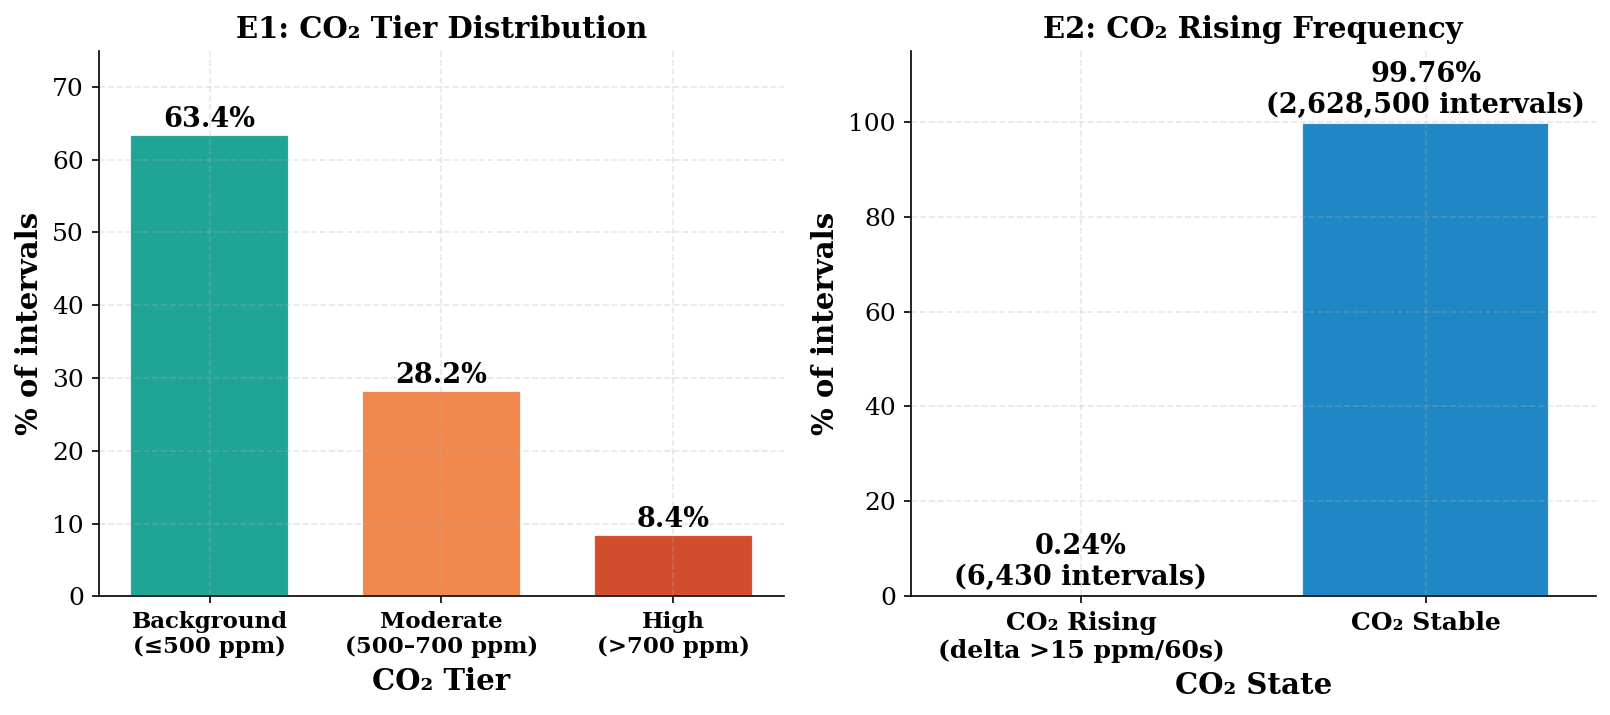

In [45]:
# Fig 02-A — CO₂ Tier Distribution (E1) + CO₂ Rising Rate (E2)
tiers  = ['background','moderate','high']
xlabs  = ['Background\n(≤500 ppm)','Moderate\n(500–700 ppm)','High\n(>700 ppm)']
pcts   = df['e1_co2_tier'].value_counts(normalize=True).reindex(tiers).fillna(0)*100
rising_count = int(df['e2_co2_rising'].sum())
rising_rate  = float(df['e2_co2_rising'].mean()*100)
stable_rate  = 100 - rising_rate

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

# left: E1 CO2 tier distribution -- bring tiers closer together
x0 = np.arange(len(xlabs)) * 0.8
bars = axes[0].bar(x0, pcts.values, 0.55,
                    color=[C['green'],C['orange'],C['red']],
                    alpha=0.88, edgecolor='white')
for bar, v in zip(bars, pcts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=13,fontweight='bold')
axes[0].set_xticks(x0)
axes[0].set_xticklabels(xlabs, fontsize=11, fontweight='bold')
axes[0].margins(x=0.05)
axes[0].set_ylabel('% of intervals', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=12)
axes[0].set_xlabel('CO\u2082 Tier', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 75)
axes[0].set_title('E1: CO\u2082 Tier Distribution', fontsize=14, fontweight='bold')

# right: E2 — linear scale, annotate count to show rarity
stable_count = int(len(df) - rising_count)
x1 = np.arange(2) * 0.7
bars2 = axes[1].bar(
    x1,
    [rising_rate, stable_rate], 0.5,
    color=[C['red'], C['blue']], alpha=0.88, edgecolor='white'
)
for bar, v, cnt in zip(bars2, [rising_rate, stable_rate],
                        [rising_count, stable_count]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.8,
                 f'{v:.2f}%\n({cnt:,} intervals)',
                 ha='center', va='bottom', fontsize=13,fontweight='bold')
axes[1].set_xticks(x1)
axes[1].set_xticklabels(['CO\u2082 Rising\n(delta >15 ppm/60s)', 'CO\u2082 Stable'],
                        fontsize=12, fontweight='bold')
axes[1].margins(x=0.08)
axes[1].set_ylabel('% of intervals', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_xlabel('CO\u2082 State', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 115)
axes[1].set_title('E2: CO\u2082 Rising Frequency', fontsize=14, fontweight='bold')

# fig.suptitle('Occupancy Events Distribution (E1, E2)',
#              fontsize=12, fontweight='bold')
fig.tight_layout()
fig.subplots_adjust(top=0.82)   # prevent suptitle collision
save_fig(fig, '02_a_co2_distribution')

## 2 · Temporal Events  *(§6.2)*

Converted to `Europe/Berlin` local time — handles both DST transitions  
(October 2024 and March 2025) automatically.

| Event | Definition |
|-------|-----------|
| E3 | Office hours — weekday AND 08:00–17:59 |
| E4 | Season — autumn / winter / spring / summer across the campaign |


In [46]:
# local time — required for correct hour/weekday extraction across DST boundaries
local = df['time'].dt.tz_convert('Europe/Berlin')
df['hour']      = local.dt.hour
df['dayofweek'] = local.dt.dayofweek   # 0=Monday, 6=Sunday
df['month']     = local.dt.month

# E3: office hours — weekday AND 08:00–17:59
df['is_weekday'] = (df['dayofweek'] < 5).astype(int)

df['e3_office_hours'] = (
    (df['is_weekday'] == 1) & df['hour'].between(8, 17)
).astype(int)

# E4: season
df['e4_season'] = df['month'].map({
     9: 'autumn', 10: 'autumn', 11: 'autumn',
    12: 'winter',  1: 'winter',  2: 'winter',
     3: 'spring',  4: 'spring',  5: 'spring',
     6: 'summer',  7: 'summer',  8: 'summer',
})

print(f'Office hours (E3): {df["e3_office_hours"].mean()*100:.1f}%')
print(f'Season (E4)      : {df["e4_season"].value_counts().to_dict()}')

Office hours (E3): 29.2%
Season (E4)      : {'autumn': 703823, 'spring': 688573, 'summer': 648905, 'winter': 593629}


  Saved: figures/02_b_temporal_distributions


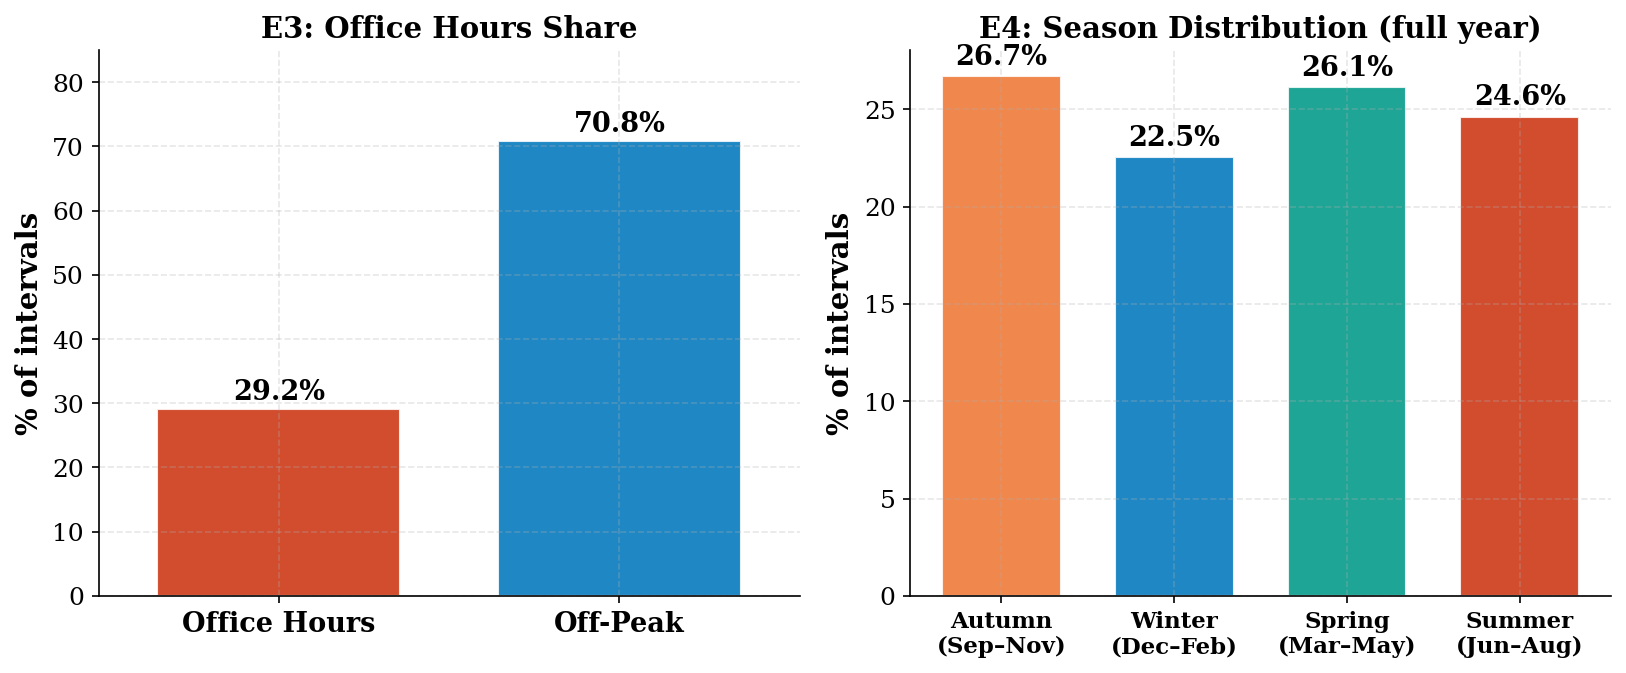

In [47]:
# Fig 02-B — Temporal Event Distributions (E3–E4)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.65))

# E3: office hours -- bring bars closer together
oh = df['e3_office_hours'].mean()*100
x0 = np.arange(2) * 0.7
axes[0].bar(x0, [oh, 100-oh], 0.5,
             color=[C['red'],C['blue']], alpha=0.88, edgecolor='white')
for xi, v in zip(x0, [oh, 100-oh]):
    axes[0].text(xi, v+0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=13,fontweight='bold')
axes[0].set_xticks(x0)
axes[0].set_xticklabels(['Office Hours','Off-Peak'], fontsize=13, fontweight='bold')
axes[0].margins(x=0.1)
axes[0].set_ylim(0, 85)
axes[0].set_ylabel('% of intervals', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=12)
axes[0].set_title('E3: Office Hours Share', fontsize=14, fontweight='bold')

# E4: season
seasons = ['autumn','winter','spring','summer']
slabs = ['Autumn\n(Sep–Nov)','Winter\n(Dec–Feb)','Spring\n(Mar–May)','Summer\n(Jun–Aug)']
scounts = [df['e4_season'].eq(s).mean()*100 for s in seasons]
x1 = np.arange(len(seasons)) * 0.8
bars = axes[1].bar(x1, scounts, 0.55,
                    color=[C['orange'],C['blue'],C['green'],C['red']],
                    alpha=0.88, edgecolor='white')
for bar, v in zip(bars, scounts):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=13,fontweight='bold')
axes[1].set_xticks(x1)
axes[1].set_xticklabels(slabs, fontsize=11, fontweight='bold')
axes[1].margins(x=0.05)
axes[1].set_ylabel('% of intervals', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_title('E4: Season Distribution (full year)', fontsize=14, fontweight='bold')

# fig.suptitle('Temporal Event Distribution (E3–E4)', fontsize=10, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_b_temporal_distributions')

## 3 · Air Quality Events — PM2.5  *(§6.3)*

PM2.5 correlates with human activity bursts — cleaning, printing, cooking —  
rather than directly attenuating 868 MHz signals.

Device-specific 90th percentile thresholds for E5 account for location differences:  
ED4 (server room) baseline = 0.79 µg/m³ vs ED5 (kitchen) baseline = 6.28 µg/m³.  
A global threshold would over-flag ED5 and under-flag ED4.

| Event | Definition |
|-------|-----------|
| E5    | PM2.5 spike: above device-specific 90th percentile |
| E6    | PM2.5 absolute tier: clean (≤10) / moderate (10–25) / elevated (>25 µg/m³), WHO Global Air Quality Guidelines |


In [48]:
# E5: absolute WHO-aligned tier
df['e5_pm25_tier'] = pd.cut(
    df['pm25'],
    bins=[-0.01, 10, 25, 10_000],
    labels=['clean', 'moderate', 'elevated']
)

# E6: device-specific PM2.5 spike — 90th percentile per device
pm25_q90 = df.groupby('device_id')['pm25'].transform(lambda x: x.quantile(0.90))
df['e6_pm25_spike'] = (df['pm25'] > pm25_q90).astype(int)

print('PM2.5 tier distribution (E5):')
print(df['e5_pm25_tier'].value_counts(normalize=True).mul(100).round(1).to_string())
print('\nDevice-specific PM2.5 90th percentile thresholds (E6):')
print(df.groupby('device_id')['pm25'].quantile(0.90).round(2).to_string())

PM2.5 tier distribution (E5):
e5_pm25_tier
clean       98.7
moderate     1.3
elevated     0.0

Device-specific PM2.5 90th percentile thresholds (E6):
device_id
ED0    4.54
ED1    4.66
ED2    4.40
ED3    4.85
ED4    1.01
ED5    6.49


  Saved: figures/02_c_pm25_events


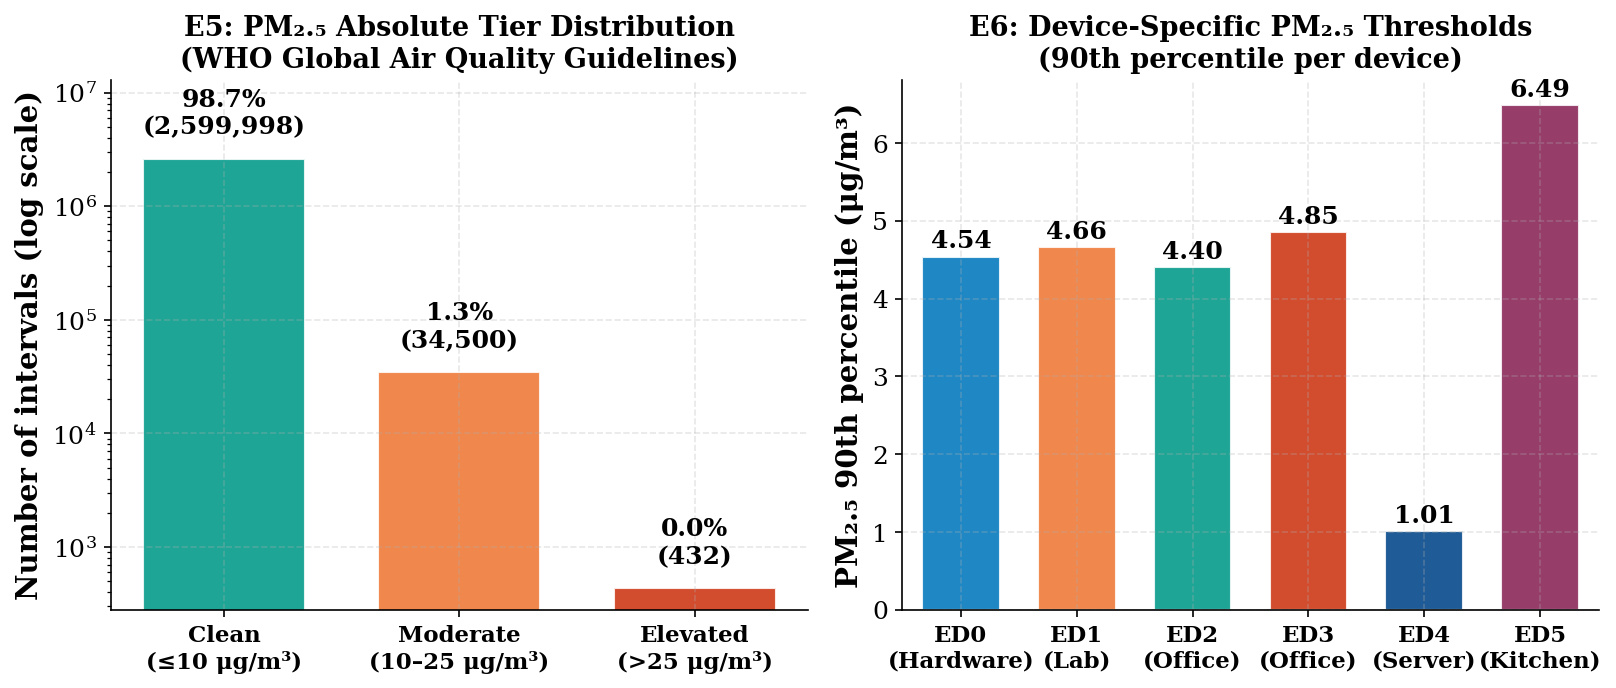

In [49]:
# Device labels with room names — define once, use everywhere
DEVICE_LABELS = {
    'ED0': 'ED0\n(Hardware)',
    'ED1': 'ED1\n(Lab)',
    'ED2': 'ED2\n(Office)',
    'ED3': 'ED3\n(Office)',
    'ED4': 'ED4\n(Server)',
    'ED5': 'ED5\n(Kitchen)',
}

# Fig 02-C — PM2.5 Events (E5, E6)
fig, axes = plt.subplots(1, 2, figsize=(11,4.75))

# E5: absolute tier distribution
tiers  = ['clean','moderate','elevated']
tlabs  = ['Clean\n(\u226410\u00a0\u03bcg/m\u00b3)',
          'Moderate\n(10\u201325\u00a0\u03bcg/m\u00b3)',
          'Elevated\n(>25\u00a0\u03bcg/m\u00b3)']
loss_str = df['e5_pm25_tier'].astype(str)
t_pcts   = [float((loss_str == t).mean()*100) for t in tiers]
t_counts = [int((loss_str == t).sum()) for t in tiers]

x0 = np.arange(len(tlabs)) * 0.8
bars2 = axes[0].bar(x0, t_counts, 0.55,
                     color=[C['green'],C['orange'],C['red']],
                     alpha=0.88, edgecolor='white')
for bar, v, cnt, pct in zip(bars2, t_counts, t_counts, t_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v * 1.5,
                 f'{pct:.1f}%\n({v:,})', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
axes[0].set_xticks(x0)
axes[0].set_xticklabels(tlabs, fontsize=11, fontweight='bold')
axes[0].margins(x=0.05)
axes[0].set_yscale('log')
axes[0].set_ylim(top=max(t_counts) * 5)
axes[0].set_ylabel('Number of intervals (log scale)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=12)
axes[0].set_title('E5: PM\u2082.\u2085 Absolute Tier Distribution\n'
                   '(WHO Global Air Quality Guidelines)', fontsize=13, fontweight='bold')

# E6: device-specific 90th percentile thresholds
devices  = sorted(df['device_id'].unique())
dlabs    = [DEVICE_LABELS.get(d, d) for d in devices]
thresh   = df.groupby('device_id')['pm25'].quantile(0.90).reindex(devices).values
colors_d = [C['blue'],C['orange'],C['green'],C['red'],C['navy'],C['brown']]

x1 = np.arange(len(dlabs)) * 0.82
bars = axes[1].bar(x1, thresh, 0.55, color=colors_d,
                    alpha=0.88, edgecolor='white')
for bar, v in zip(bars, thresh):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_xticks(x1)
axes[1].set_xticklabels(dlabs, fontsize=11, fontweight='bold')
axes[1].margins(x=0.03)
axes[1].set_ylabel('PM\u2082.\u2085 90th percentile (\u03bcg/m\u00b3)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_title('E6: Device-Specific PM\u2082.\u2085 Thresholds\n'
                   '(90th percentile per device)', fontsize=13, fontweight='bold')

# fig.suptitle('Air Quality Events Distribution (E5, E6)',
#              fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_c_pm25_events')

## 4 · Atmospheric Events  *(§6.4)*

| Event | Definition |
|-------|-----------|
| E7    | Temperature tier: cool (≤21.9°C) / moderate (21.9–25.3°C) / warm (>25.3°C) — tertiles of the deployment distribution |
| E8    | Humidity tier: dry (<30%) / normal (30–60%) / humid (>60%) — ASHRAE 55 comfort boundaries |


In [50]:
# E7: temperature tier — tertiles of the deployment distribution (locked thresholds)
df['e7_temp_tier'] = pd.cut(
    df['temperature'],
    bins=[-100, 21.9, 25.3, 100],
    labels=['cool', 'moderate', 'warm']
)

# E8: humidity tier — ASHRAE 55 comfort boundaries
df['e8_humidity_tier'] = pd.cut(
    df['humidity'],
    bins=[0, 30, 60, 100],
    labels=['dry', 'normal', 'humid']
)

print(f'Temperature range: {df["temperature"].min():.1f} – {df["temperature"].max():.1f} °C')
print(f'Humidity range   : {df["humidity"].min():.1f} – {df["humidity"].max():.1f} %')
print(f'\nE7 tertile thresholds: 21.9°C / 25.3°C')
print('E7 temperature tier distribution:')
print(df['e7_temp_tier'].value_counts(normalize=True).mul(100).round(1).astype(str).add('%').to_string())


Temperature range: 13.7 – 46.3 °C
Humidity range   : 14.0 – 62.8 %

E7 tertile thresholds: 21.9°C / 25.3°C
E7 temperature tier distribution:
e7_temp_tier
moderate    33.7%
cool        33.3%
warm        33.1%


  Saved: figures/02_d_atmospheric_distributions


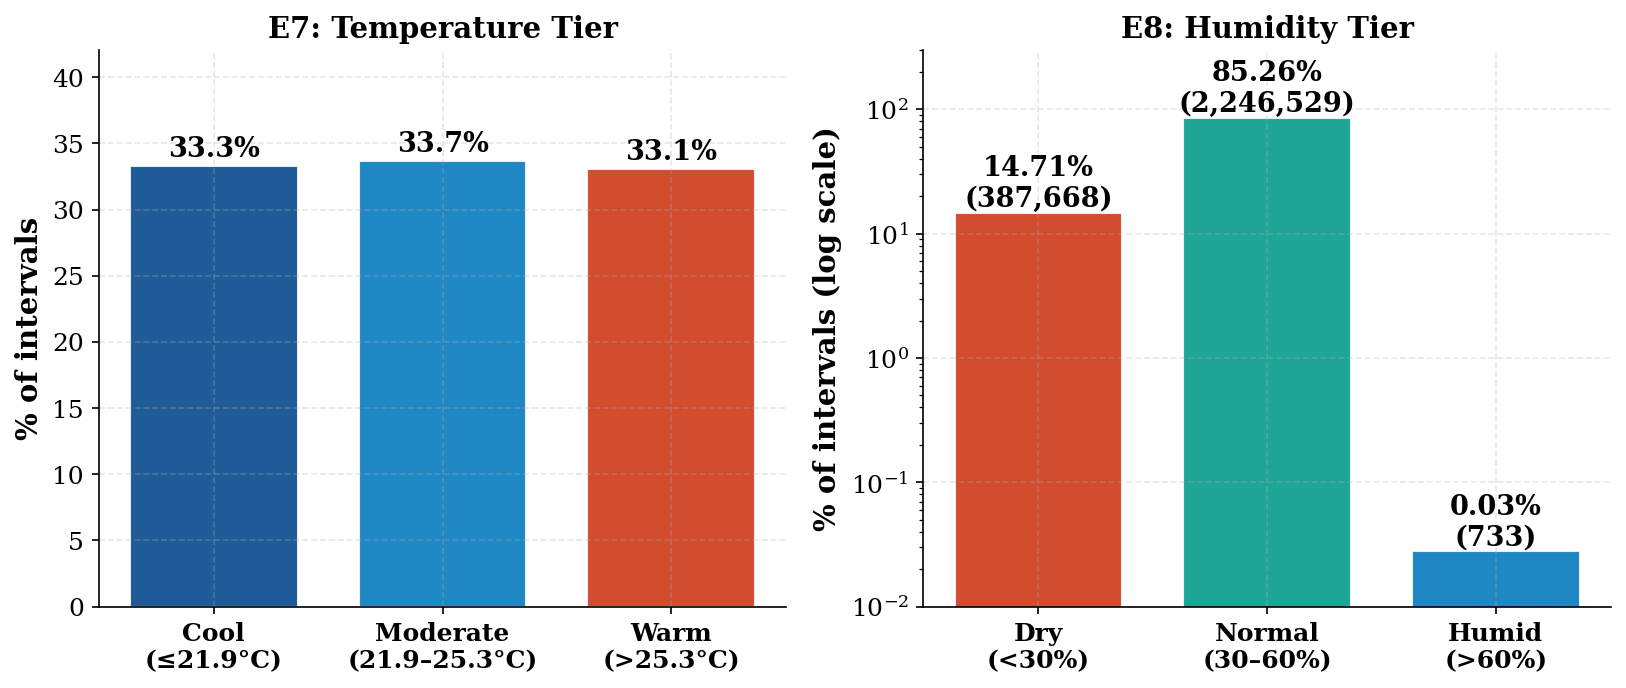

In [51]:
# Fig 02-D — Atmospheric Event Distributions (E7–E8)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.75))

# E7: temperature tier — 3 absolute tiers
tt      = ['cool', 'moderate', 'warm']
tt_labs = ['Cool\n(≤21.9°C)', 'Moderate\n(21.9–25.3°C)', 'Warm\n(>25.3°C)']
tt_pcts = [float(df['e7_temp_tier'].eq(t).mean()*100) for t in tt]
x0 = np.arange(len(tt_labs)) * 0.75
bars = axes[0].bar(x0, tt_pcts, 0.55,
                    color=[C['navy'], C['blue'], C['red']],
                    alpha=0.88, edgecolor='white')
for bar, v in zip(bars, tt_pcts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_xticks(x0)
axes[0].set_xticklabels(tt_labs, fontsize=12, fontweight='bold')
axes[0].margins(x=0.05)
axes[0].set_ylabel('% of intervals', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=12)
axes[0].set_ylim(0, max(tt_pcts)*1.25)
axes[0].set_title('E7: Temperature Tier', fontsize=14, fontweight='bold')

# E8: humidity tier — ASHRAE 55 comfort range
ht      = ['dry', 'normal', 'humid']
ht_labs = ['Dry\n(<30%)', 'Normal\n(30–60%)', 'Humid\n(>60%)']
ht_pcts   = [float(df['e8_humidity_tier'].eq(t).mean()*100) for t in ht]
ht_counts = [int(df['e8_humidity_tier'].eq(t).sum()) for t in ht]
x1 = np.arange(len(ht_labs)) * 0.75
bars = axes[1].bar(x1, ht_pcts, 0.55,
                    color=[C['red'], C['green'], C['blue']],
                    alpha=0.88, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_ylim(bottom=0.01, top=300)
for bar, v, cnt in zip(bars, ht_pcts, ht_counts):
    if v > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, v,
                     f'{v:.2f}%\n({cnt:,})', ha='center', va='bottom',
                     fontsize=13, fontweight='bold')
axes[1].set_xticks(x1)
axes[1].set_xticklabels(ht_labs, fontsize=12, fontweight='bold')
axes[1].margins(x=0.05)
axes[1].set_ylabel('% of intervals (log scale)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_title('E8: Humidity Tier', fontsize=14, fontweight='bold')

# fig.suptitle('Atmospheric Events Distribution (E7\u2013E8)',
#              fontsize=12, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_d_atmospheric_distributions')

In [52]:
print(df.groupby('e4_season')['temperature'].mean().round(1))

e4_season
autumn    22.9
spring    23.9
summer    27.9
winter    20.0
Name: temperature, dtype: float64


## 5 · Spreading Factor Event  *(§6.5)*

SF directly controls Time-on-Air (ToA) — the duration a packet occupies the channel.  
Under LoRaWAN's ALOHA protocol, longer ToA = wider collision window = higher loss probability.

ADR was disabled. SF rotated in a fixed cycle: SF12→SF11→SF10→SF9→SF8→SF7.  
SF11/SF12 blocks are truncated to 4 packets by duty cycle enforcement (§5.2.1).

| SF | ToA (ms) | Collision window vs SF7 |
|----|---------|------------------------|
| 7 | 71.9 | baseline |
| 8 | 133.6 | 1.9× |
| 9 | 246.8 | 3.4× |
| 10 | 452.6 | 6.3× |
| 11 | 987.1 | 13.7× |
| 12 | 1810.4 | 25.2× |

| Event | Definition |
|-------|-----------|
| E9   | SF categorical: 7 / 8 / 9 / 10 / 11 / 12 |


In [53]:
# E9: individual SF value
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}
df['e9_sf'] = df['SF'].astype(int)

print('SF Distribution (E10):')
for sf in [7,8,9,10,11,12]:
    n = (df['e9_sf']==sf).sum()
    print(f'  SF{sf} (ToA={TOA_MS[sf]:7.1f}ms): {n:,} ({n/len(df)*100:.1f}%)')



SF Distribution (E10):
  SF7 (ToA=   71.9ms): 537,023 (20.4%)
  SF8 (ToA=  133.6ms): 534,546 (20.3%)
  SF9 (ToA=  246.8ms): 518,734 (19.7%)
  SF10 (ToA=  452.6ms): 500,838 (19.0%)
  SF11 (ToA=  987.1ms): 269,220 (10.2%)
  SF12 (ToA= 1810.4ms): 274,569 (10.4%)


  Saved: figures/02_e_sf_distribution


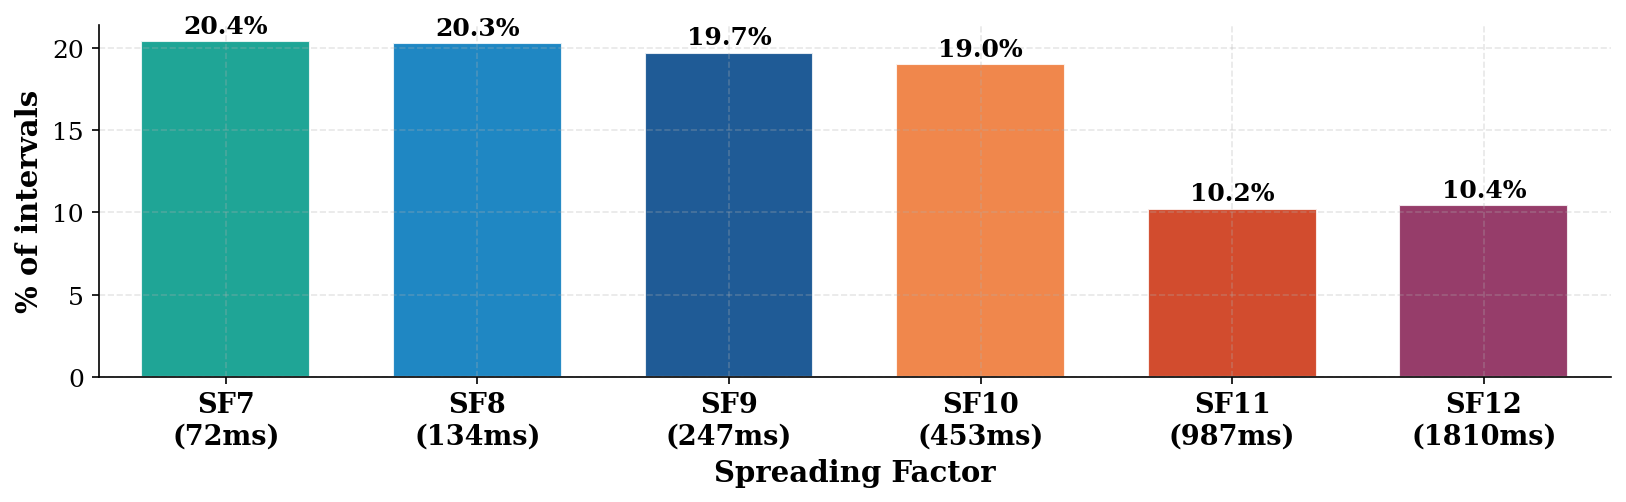

In [54]:
# Fig 02-E — SF Distribution (E10)
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}
fig, ax = plt.subplots(figsize=(11, 3.5))

sfs = [7,8,9,10,11,12]
sf_xlabs  = [f'SF{sf}\n({TOA_MS[sf]:.0f}ms)' for sf in sfs]
sf_pcts   = [df['e9_sf'].eq(sf).mean()*100 for sf in sfs]
sf_colors = [C['green'],C['blue'],C['navy'],C['orange'],C['red'],C['brown']]
x = np.arange(len(sf_xlabs)) * 0.82
w = 0.55
bars = ax.bar(x, sf_pcts, w, color=sf_colors, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, sf_pcts):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=12,fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sf_xlabs, fontsize=13, fontweight='bold')
ax.margins(x=0.03)
ax.set_ylabel('% of intervals', fontsize=14, fontweight='bold')
ax.set_xlabel('Spreading Factor', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
# ax.set_title('E9: ')

# fig.suptitle('Spreading Factor Event Distribution (E9)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_e_sf_distribution')


## 6 · Signal Context Event  *(§6.6)*

ESP (effective signal power) is only available for received packets — never for lost ones.  
E10 uses the signal quality of the packet received immediately before the loss interval  
as a proxy for channel state at the time of loss.

| Event | Definition |
|-------|-----------|
| E10   | ESP tier: ThingPark Enterprise six-tier classification (critical / very_weak / weak / fair / good / excellent), based on Abdelghany 2021 |


In [55]:
# E10: ESP tier — collapsed to 3 analytical tiers from ThingPark 6-band classification
# poor    = critical + very_weak  (below -120 dBm)
# moderate = weak + fair          (-120 to -100 dBm)
# strong  = good + excellent      (above -100 dBm)
df['e10_esp_tier'] = pd.cut(
    df['esp'],
    bins   = [-300, -120, -100, 0],
    labels = ['poor', 'moderate', 'strong']
)

print("ESP tier distribution (E10) — 3 analytical tiers:")
print(df['e10_esp_tier'].value_counts(normalize=True)
      .mul(100).round(2)
      .reindex(['poor', 'moderate', 'strong'])
      .to_string())
print(f"\nRaw counts:")
print(df['e10_esp_tier'].value_counts()
      .reindex(['poor', 'moderate', 'strong'])
      .to_string())

ESP tier distribution (E10) — 3 analytical tiers:
e10_esp_tier
poor         8.73
moderate     4.41
strong      86.86

Raw counts:
e10_esp_tier
poor         230117
moderate     116207
strong      2288606


  Saved: figures/02_f_signal_quality_distribution


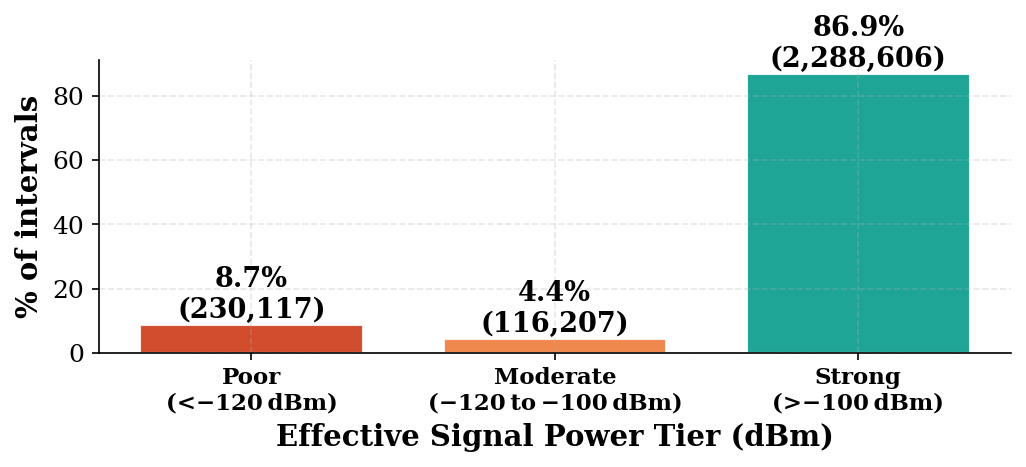

In [56]:
# Fig 02-F — Signal Quality Event (E10) — 3 analytical tiers
et      = ['poor', 'moderate', 'strong']
et_labs = ['Poor\n(<−120\u202fdBm)', 'Moderate\n(−120\u202fto\u202f−100\u202fdBm)', 'Strong\n(>−100\u202fdBm)']
et_pcts   = [float((df['e10_esp_tier'].astype(str) == t).mean() * 100) for t in et]
et_counts = [int((df['e10_esp_tier'].astype(str) == t).sum()) for t in et]
et_colors = [C['red'], C['orange'], C['green']]

fig, ax = plt.subplots(figsize=(7, 3.25))
x = np.arange(len(et_labs)) * 0.75
bars = ax.bar(x, et_pcts, 0.55, color=et_colors,
               alpha=0.88, edgecolor='white')

for bar, v, cnt in zip(bars, et_pcts, et_counts):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3,
            f'{v:.1f}%\n({cnt:,})', ha='center', va='bottom',
            fontsize=13, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(et_labs, fontsize=11, fontweight='bold')
ax.margins(x=0.05)
ax.set_ylabel('% of intervals', fontsize=14, fontweight='bold')
ax.set_xlabel('Effective Signal Power Tier (dBm)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
# fig.suptitle('Signal Quality Event Distribution (E10)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '02_f_signal_quality_distribution')

## 7 · Burst Loss Event  *(§6.7)*

Classifies each interval by the number of consecutive packets lost before the received packet.  
Burst loss is qualitatively different from isolated loss — it creates contiguous data gaps  
that cannot be recovered by interpolation.

**B=3 threshold:** 3 consecutive losses = 3-minute gap at 60s TX interval — the minimum  
gap that visibly disrupts slowly-varying environmental signals (CO₂, temperature).

| Class | Condition | Interpretation |
|-------|-----------|---------------|
| no_loss | 0 | Clean reception |
| isolated | 1 | Single random collision |
| small_burst | 2–4 | Brief channel degradation |
| large_burst | ≥5 | Sustained interference episode |


In [57]:
# Burst loss characterisation — descriptive only, NOT an event predictor
# Classifies each interval by tx_loss magnitude for Figure 02-G
# This column is used for descriptive analysis only and is excluded
# from all Mann-Whitney tests and logistic regression (outcome circularity)
df['loss_type'] = pd.cut(
    df['tx_loss'],
    bins=[-1, 0, 1, 4, 10_000_000],
    labels=['no_loss', 'isolated', 'small_burst', 'large_burst']
)

print('Burst loss distribution (descriptive):')
print(df['loss_type'].value_counts(normalize=True).mul(100).round(2).astype(str).add('%').to_string())


Burst loss distribution (descriptive):
loss_type
no_loss        98.34%
isolated        1.33%
small_burst     0.27%
large_burst     0.05%


  Saved: figures/02_g_burst_loss_distribution


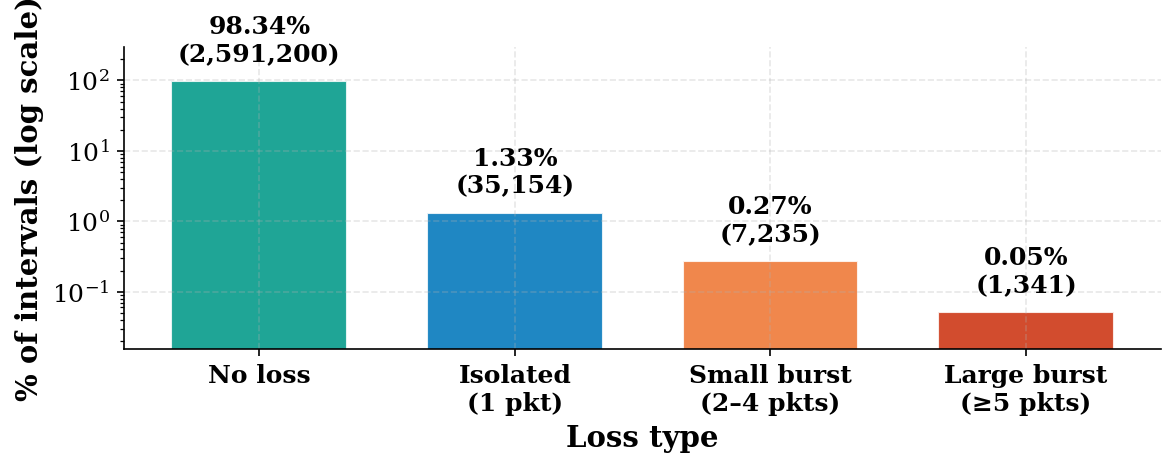

In [58]:
# Fig 02-G — Burst Loss Distribution (single log panel)
order  = ['no_loss', 'isolated', 'small_burst', 'large_burst']
olabs  = ['No loss', 'Isolated\n(1 pkt)', 'Small burst\n(2–4 pkts)', 'Large burst\n(≥5 pkts)']

# cast to string first to bypass Categorical comparison issues
loss_str = df['loss_type'].astype(str)
o_pcts   = [float((loss_str == o).mean() * 100) for o in order]
o_counts = [int((loss_str == o).sum()) for o in order]

fig, ax = plt.subplots(figsize=(8, 3.25))
x = np.arange(len(olabs)) * 0.8
bars = ax.bar(x, o_pcts, 0.55,
               color=[C['green'], C['blue'], C['orange'], C['red']],
               alpha=0.88, edgecolor='white')
ax.set_yscale('log')
ax.set_ylim(
    bottom=min(v for v in o_pcts if v > 0) * 0.3,
    top=max(o_pcts) * 3
)
for bar, v, cnt in zip(bars, o_pcts, o_counts):
    ax.text(bar.get_x()+bar.get_width()/2, v * 1.6,
            f'{v:.2f}%\n({cnt:,})', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(olabs, fontsize=12, fontweight='bold')
ax.margins(x=0.05)
ax.set_ylabel('% of intervals (log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('Loss type', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
# ax.set_title('Burst Loss Characterisation — all categories on log scale')
fig.tight_layout()
save_fig(fig, '02_g_burst_loss_distribution')

## 8 · Event Taxonomy  *(Table 6.1)*

Complete list of all 10 events — copy to Table 6.1 in the thesis.


In [59]:
# Event Taxonomy — 10 events E1–E10
event_taxonomy = [
    ('E1',  'Occupancy',      'e1_co2_tier',      'CO2 concentration tier (background/moderate/high)'),
    ('E2',  'Occupancy',      'e2_co2_rising',     'CO2 rising > 15ppm/60s'),
    ('E3',  'Temporal',       'e3_office_hours',   'Office hours — weekday AND 08:00–17:59'),
    ('E4',  'Temporal',       'e4_season',         'Season (autumn/winter/spring/summer)'),
    ('E5',  'Air Quality',    'e5_pm25_tier',      'PM2.5 absolute tier (clean/moderate/elevated)'),
    ('E6',  'Air Quality',    'e6_pm25_spike',     'PM2.5 device-specific 90th percentile spike'),
    ('E7',  'Atmospheric',    'e7_temp_tier',      'Temperature tertile tier (cool/moderate/warm)'),
    ('E8',  'Atmospheric',    'e8_humidity_tier',  'Relative humidity tier (dry/normal/humid)'),
    ('E9', 'Spreading Factor',      'e9_sf',            'Spreading factor (SF7–SF12)'),
    ('E10', 'Signal Quality', 'e10_esp_tier',      'ESP tier: poor (<-120 dBm) / moderate (-120 to -100 dBm) / strong (>-100 dBm)'),
]

print(f"{'ID':<5} {'Family':<15} {'Column':<22} {'Definition'}")
print('-'*80)
for row in event_taxonomy:
    print(f'{row[0]:<5} {row[1]:<15} {row[2]:<22} {row[3]}')
print(f'\nTotal: {len(event_taxonomy)} events across 6 families (E1–E10)')


ID    Family          Column                 Definition
--------------------------------------------------------------------------------
E1    Occupancy       e1_co2_tier            CO2 concentration tier (background/moderate/high)
E2    Occupancy       e2_co2_rising          CO2 rising > 15ppm/60s
E3    Temporal        e3_office_hours        Office hours — weekday AND 08:00–17:59
E4    Temporal        e4_season              Season (autumn/winter/spring/summer)
E5    Air Quality     e5_pm25_tier           PM2.5 absolute tier (clean/moderate/elevated)
E6    Air Quality     e6_pm25_spike          PM2.5 device-specific 90th percentile spike
E7    Atmospheric     e7_temp_tier           Temperature tertile tier (cool/moderate/warm)
E8    Atmospheric     e8_humidity_tier       Relative humidity tier (dry/normal/humid)
E9    Spreading Factor e9_sf                  Spreading factor (SF7–SF12)
E10   Signal Quality  e10_esp_tier           ESP tier: poor (<-120 dBm) / moderate (-120 to -100 dBm) 

## Save  *(2_events.csv)*

| Group | Columns |
|-------|---------|
| Original | all columns from `1_reconstructed.csv` |
| Occupancy | `e1_co2_tier`, `e2_co2_rising` |
| Temporal | `e3_office_hours`, `e4_season` |
| Air Quality | `e5_pm25_spike`, `e6_pm25_tier` |
| Atmospheric | `e7_temp_tier`, `e8_humidity_tier` |
| Spreading Factor | `e9_sf` |
| Signal Quality | `e10_esp_tier` |
| Burst Loss (descriptive) | `loss_type` |


In [60]:
original_cols = [c for c in df.columns
                 if not (c.startswith('e') and '_' in c)
                 and c not in ['hour', 'dayofweek', 'month', 'exp_pl']]

event_cols_ordered = [
    'e1_co2_tier',   'e2_co2_rising',
    'e3_office_hours', 'e4_season',
    'e5_pm25_tier', 'e6_pm25_spike',
    'e7_temp_tier',  'e8_humidity_tier',
    'e9_sf', 'e10_esp_tier',
    'loss_type',
]

df = df[[c for c in original_cols if c in df.columns] +
        [c for c in event_cols_ordered if c in df.columns]]
df.to_csv(DATA_DIR / '2_events.csv', index=False)

print(f'Saved  : {DATA_DIR / "2_events.csv"}')
print(f'Rows   : {len(df):,}')
print(f'Columns: {len(df.columns)} total | 10 events (E1–E10) + loss_type')


Saved  : ..\data\2_events.csv
Rows   : 2,634,930
Columns: 39 total | 10 events (E1–E10) + loss_type
